═══════════════════════════════════════════════
  ## **DAY 6 — GRADIENT DESCENT**
═══════════════════════════════════════════════
  #### **Week 1 · Day 6 of 84**
───────────────────────────────────────────────
  **Today's objectives**
  • Why (XᵀX)⁻¹ breaks down at production scale

  • Loss surface intuition — "walking downhill"

  • Gradient Descent from scratch on the SSE loss

  • Learning rate, convergence, and divergence
  Deliverables

  • GradientDescentScratch implementation

  • Compare convergence vs Normal Equation weights
═══════════════════════════════════════════════

#### Matrix inversion is roughly O(n³) — cubic, not linear.

The answer: matrix inversion is roughly O(n³) — cubic, not linear.

Here's why, in plain terms. Computing an inverse (or solving XᵀXw = Xᵀy) isn't one operation — under the hood it's something like Gaussian elimination: for every row, you sweep through and cancel out that column in every other row. That's roughly n rows × n columns × n operations-per-cancellation ≈ n³ total multiply-adds. Double n, and work goes up by 2³ = 8x. Triple it, and work goes up 3³ = 27x. That's not something vectorization can escape — vectorization just makes each of those n³ operations run faster in hardware, it doesn't reduce how many there are.

Check it against your own numbers: n=5000 → n=10000 is 2x the size, and time went from 8.4s to 53s — that's ~6.3x, right in the ballpark of the 8x cubic prediction (some noise from memory/cache effects at these sizes, but the shape is unmistakably cubic, not linear).

In [10]:
from statistics import LinearRegression

import numpy as np
import time

sizes = [2, 100, 1000, 5000, 10000]

for n in sizes:
    A = np.random.randn(n, n)
    A = A @ A.T + np.eye(n) * n  # make it well-conditioned & invertible

    start = time.perf_counter()
    inv_A = np.linalg.inv(A)
    elapsed = time.perf_counter() - start

    print(f"n={n:>6} -> time = {elapsed:.6f} sec")

n=     2 -> time = 0.083418 sec
n=   100 -> time = 0.037255 sec
n=  1000 -> time = 0.248404 sec
n=  5000 -> time = 3.422871 sec
n= 10000 -> time = 21.517418 sec


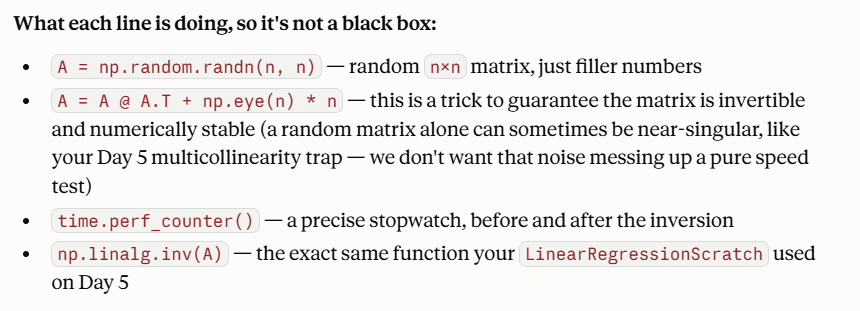

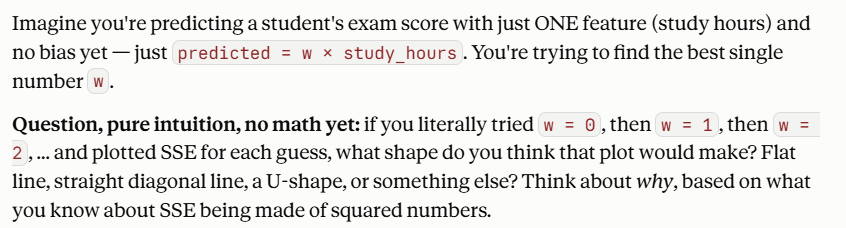

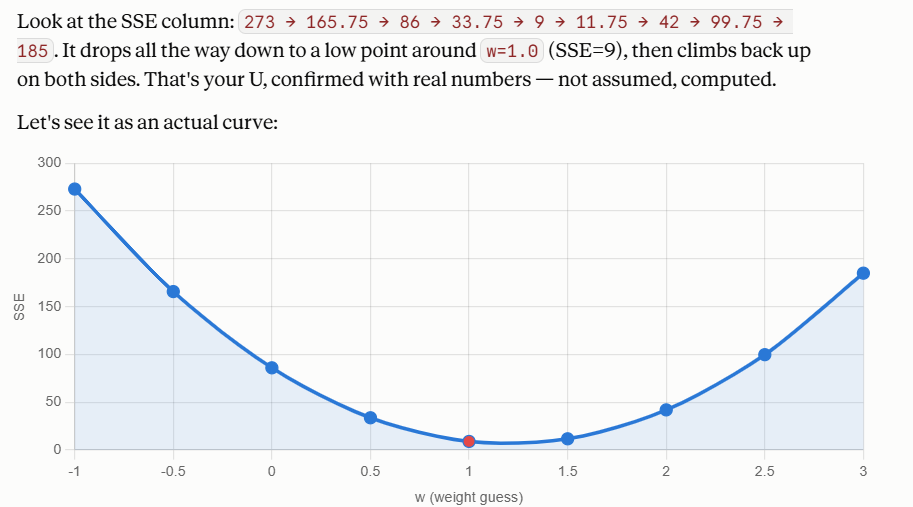

In [15]:
import numpy as np
from sklearn.linear_model import LinearRegression

class GradientDescentScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def fit(self, X, y):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        n_samples = X_b.shape[0]

        self.w = np.zeros(X_b.shape[1])   # start at all-zero weights

        for i in range(self.n_iterations):
            predictions = X_b @ self.w         # <- fill in (1 line)
            gradient = -2 * X_b.T @ (y - predictions)               # <- fill in (1 line)
            self.w = self.w - self.learning_rate * gradient
            sse = np.sum((y - predictions) ** 2)
            self.loss_history.append(sse)

        return self

    def predict(self, X):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        return X_b @ self.w

In [16]:
# student dataset from Day 5: study_hours, sleep_hours, practice_tests -> exam_score
X = np.array([
    [1, 6, 1],
    [2, 7, 2],
    [3, 6, 2],
    [4, 8, 3],
    [5, 7, 4],
    [6, 8, 5],
    [7, 9, 6],
], dtype=float)
y = np.array([50, 55, 60, 68, 72, 80, 88], dtype=float)

In [17]:
# normalize features so gradient descent behaves (each column mean 0, std 1)
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_scaled = (X - X_mean) / X_std

gd = GradientDescentScratch(learning_rate=0.05, n_iterations=2000)
gd.fit(X_scaled, y)

sk = LinearRegression()
sk.fit(X_scaled, y)

print("GradientDescentScratch weights:", np.round(gd.w, 4))
print("sklearn bias + coefs        :", np.round(np.concatenate([[sk.intercept_], sk.coef_]), 4))

GradientDescentScratch weights: [67.5714  9.7273  1.2643  1.8174]
sklearn bias + coefs        : [67.5714  9.7273  1.2643  1.8174]


### TASK 3

In [20]:
from warnings import filterwarnings
filterwarnings('ignore')

rates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

for lr in rates:
    gd = GradientDescentScratch(learning_rate=lr, n_iterations=500)
    gd.fit(X_scaled, y)
    final_sse = gd.loss_history[-1]

    if np.isnan(final_sse) or np.isinf(final_sse):
        status = "DIVERGED"
    else:
        status = "converged"

    print(f"learning_rate={lr} -> final SSE={final_sse} -> {status}")

learning_rate=0.001 -> final SSE=7.171059396142158 -> converged
learning_rate=0.01 -> final SSE=4.2558296909260545 -> converged
learning_rate=0.1 -> final SSE=inf -> DIVERGED
learning_rate=0.5 -> final SSE=nan -> DIVERGED
learning_rate=1.0 -> final SSE=nan -> DIVERGED
learning_rate=2.0 -> final SSE=nan -> DIVERGED


### TASK 4

In [21]:
iteration_counts = [10, 100, 1000, 10000]

for n_iter in iteration_counts:
    gd = GradientDescentScratch(learning_rate=0.05, n_iterations=n_iter)
    gd.fit(X_scaled, y)

    print(f"n_iterations={n_iter:>6} | final SSE={gd.loss_history[-1]:.6f} | weights={np.round(gd.w,4)}")

n_iterations=    10 | final SSE=479.238997 | weights=[67.571   3.3811 -1.0447  2.3232]
n_iterations=   100 | final SSE=4.372114 | weights=[67.5714  8.1429  0.9937  3.5148]
n_iterations=  1000 | final SSE=3.818182 | weights=[67.5714  9.7261  1.2641  1.8188]
n_iterations= 10000 | final SSE=3.818182 | weights=[67.5714  9.7273  1.2643  1.8174]
